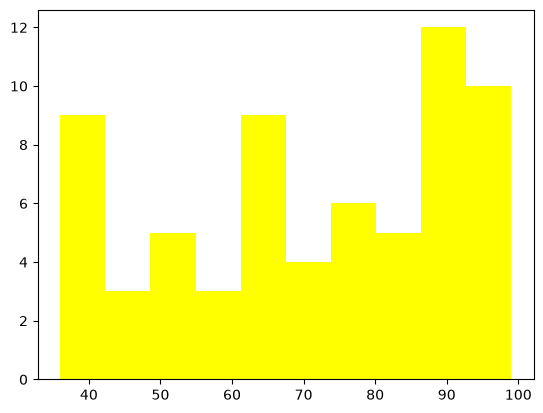

In [243]:
import json
import numpy as np
import matplotlib.pyplot as plt

def generate_function():
    global scores
    rng = np.random.default_rng(1)
    scores = rng.integers(1,100,size=100)

    print(scores)

def assing_grades():
    global grades
    global choice

    condition  = [
        (scores>=90) & (scores <=100),
        (scores>=80) & (scores <=89),
        (scores >=70) & (scores <=79),
        (scores >=60)  & (scores <=69),
        (scores >=45) & (scores <=59),
        (scores >= 33) & (scores <=44),
        (scores >=0) & (scores <33)
    ]
    choice = ["A+","A","B","B+","C+","C","D"]

    grades = np.select(condition,choice,default = 'Invalid')
    print(grades)


def calculate_statistics():
    print("mean: ",np.mean(scores))
    print("median: ",np.median(scores))
    print("std: ",np.std(scores))
    print("variance: ",np.var(scores))
    marks = int(input("Enter Marks To Find the your percentile"))
    print("percentiles: ",np.percentile(scores,q=marks))

def filter_top_performers():
    top_marks = scores[(scores>=90) & (scores<=100)]
    print("Top Marks:",top_marks)

def filter_struggling():
    strugggers = scores[(scores>=0) & (scores<=40)]
    print("Strugglers: ",strugggers)

def grade_distribution():
    with open("data.json","r") as file:
        loaded_data = json.load(file)
    count = 0
    for grade in choice:
        indicies = np.argwhere(grade==grades)
        count = len(indicies)
        percentage = (count/100) * 100
        loaded_data["distribution"].append({
            "grade":grade,
            "count":count,
            "percentage":percentage
        })
        print(loaded_data)
    with open("data.json","w") as file:
        json.dump(loaded_data,file,indent=4)
            
def display_grade_breakdown():
    value = []
    percentages = []
    with open("data.json","r") as file:
       loaded_data = json.load(file)

    for i in range(0,len(loaded_data["distribution"])):
       value.append(loaded_data["distribution"][i]["grade"])
       percentages.append(loaded_data["distribution"][i]["percentage"])

       plt.bar(value,percentages,color = "blue")

def find_top_n_student(n):
    sorted_scores = np.sort(scores)
    sorted_scores = sorted_scores[::-1]
    for i in range(n):
        print(sorted_scores[i])


def find_bottom_n_students(n):
    sorted_scores_2 = np.sort(scores)
    for i in range(n):
        print(sorted_scores_2[i])

def calculate_pass_percentage():
    passed_scores = scores[scores>=35]
    pass_percentage = (len(passed_scores) / len(scores)) * 100
    print(pass_percentage)


def display_score_histogram():
    passed_scores = scores[scores>=35]
    plt.hist(passed_scores, color="yellow")

display_score_histogram()
